**WEEK 5 SIMULATION NOTEBOOK**

Continuing on from Week 4, this week, the objectives are: 

1. Simulating the behaviour of the $\Pi$ matrices as $\varepsilon$ tends to zero, and how the error changes. 
2. Simulating the output of non-decaying signals. 
3. Simulaitng the output when $S_{11} = S_{22} = 0$

Some theoretical objectives are: 

1. Finding conditions for $\Pi_{z1}$, $\Pi_{z2}$, $\Pi_{x2}$,
2. What happens when $S_{22}$ in NOT Hurwitz?
3. Controllability and Observability, explore the connections? 

In terms of simulation, the main thing that needs to change is to be able to implement varying values of $\varepsilon$


In [60]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy.linalg as la


In [61]:
# array of small values between 0 and 1 for epsilon
epsilon_list = np.linspace(0.001, 0.201, 200)


Let us make it more general than before: 
\begin{align}
\dot{x} &= A_{11} x + A_{12} z + B_1 u \in \mathbb{R}^n \\
\varepsilon \dot{z} &= A_{21} x + A_{22} z + B_2 u \in \mathbb{R}^m
\end{align}

\begin{align}
\dot{w}_1 &= S_{11} w_1 + S_{12} w_2 \in \mathbb{R}^{N_{g1}} \\
\varepsilon \dot{w}_2 &= S_{21} w_1 + S_{22} w_1 \in \mathbb{R}^{N_{g2}}
\end{align}

\begin{equation}
u = L_{g1} w_1 + L_{g2} w_2 \in \mathbb{R}
\end{equation}

\begin{equation}
y = C_1 x + C_2 z \in \mathbb{R}
\end{equation}

Below is a general framework for solving the system dynamics for whatever system/ signal we might have. 


In [62]:
from dataclasses import dataclass

@dataclass
class SystemParams:
    n: int
    m: int
    Ng1: int
    Ng2: int
    A11: np.ndarray
    A12: np.ndarray
    A21: np.ndarray
    A22: np.ndarray
    S11: np.ndarray
    S12: np.ndarray
    S21: np.ndarray
    S22: np.ndarray
    Lg1: np.ndarray
    Lg2: np.ndarray
    B1: np.ndarray
    B2: np.ndarray
    epsilon: float

def combined_system(t, state, p: SystemParams):
    # Unpack states
    x = state[:p.n]
    z = state[p.n: p.n + p.m]
    w1 = state[p.n+p.m:p.n+p.m+p.Ng1]
    w2 = state[p.n+p.m+p.Ng1:p.n+p.m+p.Ng1+p.Ng2]

    # Input
    u = p.Lg1 @ w1 + p.Lg2 @ w2

    # Dynamics
    dx = p.A11 @ x + p.A12 @ z + p.B1.flatten() * u
    dz = (p.A21 @ x + p.A22 @ z + p.B2.flatten() * u) / p.epsilon
    dw1 = p.S11 @ w1 + p.S12 @ w2
    dw2 = (p.S21 @ w1 + p.S22 @ w2) / p.epsilon

    return np.concatenate([dx, dz, dw1, dw2])

For the system, we'll use the car suspension model once again. 
\begin{equation}
\dot{x}_1 = x_2 - z_2
\end{equation}

\begin{equation}
\dot{x}_2 = -x_1 - \beta x_2 + \beta z_2 + u
\end{equation}

\begin{equation}
\varepsilon \dot{z}_1 = z_2
\end{equation}

\begin{equation}
\varepsilon \dot{z}_2 = \alpha x_1 - \alpha \beta (z_2 - x_2) - z_1 - \alpha u 
\end{equation}

For the Signal, we want to try a non-decaying oscillatory signal:
So we'll go for something like this: (insert signal) 


In [63]:
# SETTING SYSTEM PARAMETERS

alpha = 1.0
beta = 0.5
A11 = np.array([[0., 1.],
                [-1., -beta]])
A12 = np.array([[0.,0.],
                [0.,beta]])
A21 = np.array([[0.,0.],
                [alpha, alpha * beta]])
A22 = np.array([[0., 1.0],
                [-1., -alpha * beta]])
B1 = np.array([[0.],
               [1.0]])
B2 = np.array([[0.],
               [-alpha]])

S11 = np.array([[0., -1.],
                [1. , 0.]])
S12 = np.array([[0.5, 0.2],
                [0.2 , 0.5]])
S21 = np.array([[-0.5, -0.2],
                [-0.2 ,-0.5]])
S22 = np.array([[0., -2.],
                [2. , 0.]])

#initial conditions
state0 = [1., 1., 2.,0.5, 0.5, 0.5, 0.1, 0.1]

n = len(A11)
m = len(A22)
Ng1 = len(S11)
Ng2 = len(S22)

# same Lg as week 4
Lg = np.array([[(4.0-i)**0.5 for i in range(4)]])
Lg1 = Lg[0][:2]
Lg2 = Lg[0][2:]

print(Lg1)
print(Lg2)
print(Lg)

[2.         1.73205081]
[1.41421356 1.        ]
[[2.         1.73205081 1.41421356 1.        ]]


Epsilon loop

Let's say:
\begin{align}
C_1 &= \begin{bmatrix} 1 & 1 \end{bmatrix} \\
C_2 &= \begin{bmatrix} 1 & 1 \end{bmatrix}
\end{align}


In [64]:
from mpl_toolkits.mplot3d import Axes3D

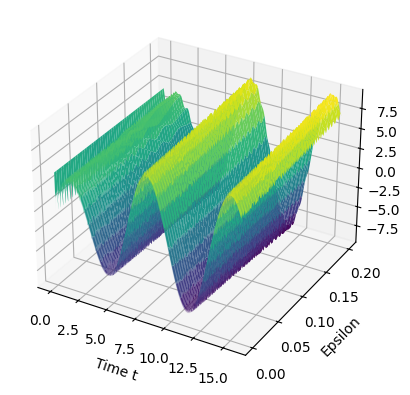

In [65]:
# Time span
t_span = (0., 5.0*np.pi)
t_eval = np.linspace(t_span[0], t_span[1], 10000)

C1 = np.array([[1.0 , 1. ]])
C2 = np.array([[1. ,1. ]])

Y_all = []
for epsilon in epsilon_list:
    parameters = SystemParams(n, m, Ng1, Ng2, A11, A12, A21, A22,
                              S11, S12, S21, S22, Lg1, Lg2, B1, B2, epsilon)
    
    # solving the system for the given value in epsilon
    sol = solve_ivp(
        lambda t, state: combined_system(t, state, parameters),
        t_span, 
        state0, 
        t_eval = t_eval, 
        method = 'Radau'
    )
    
    X = sol.y[:n, :]
    Z = sol.y[n: n + m, :]
    W1 = sol.y[ n+m: n+m+Ng1, :]
    W2 = sol.y[ n+m+Ng1: n+m+Ng1+Ng2, :]
    U = Lg1 @ W1 + Lg2 @ W2

    Y = C1 @ X + C2 @ Z
    Y_all.append(Y.flatten())

Y_all = np.array(Y_all)

# For plotting, pick one output dimension (say first one

T, E = np.meshgrid(t_eval, epsilon_list)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(T, E, Y_all, cmap='viridis')

ax.set_xlabel("Time t")
ax.set_ylabel("Epsilon")
ax.set_zlabel("Y")

plt.show()



    

    